# Modelo Explicativo de Clasificación de Urgencia y Especialidad

Este notebook implementa un modelo XGBoost con explicabilidad SHAP para clasificar:
- **Nivel de Urgencia** (1-4)
- **Especialidad Médica** requerida

El modelo proporciona:
- Predicciones precisas
- Confianza/Probabilidad en cada predicción
- Explicaciones detalladas (SHAP)
- Análisis de importancia de features

## 1. Importar Librerías

In [1]:
import pickle
from pathlib import Path
from typing import Tuple, Dict, List, Any

import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import optuna
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
)

import warnings
warnings.filterwarnings('ignore')


/home/sheng/proyectos/Hackathon-HSIL-2026/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Cargar y Explorar Datos

In [2]:
# Cargar dataset
dataset_path = "../analisis_datos/data/raw/Dataset_urgencia_especialidad.csv"
df = pd.read_csv(dataset_path)

print(f"Dataset cargado: {df.shape[0]} muestras, {df.shape[1]} features")
print(f"\nPrimeras 3 filas:")
df.head(3)

Dataset cargado: 32700 muestras, 52 features

Primeras 3 filas:


,edad,sexo,frecuencia_cardiaca,presion_sistolica,presion_diastolica,saturacion_oxigeno,frecuencia_respiratoria,temperatura,glucemia,escala_glasgow,...,Especialidad_Cirugía_cardiaca,Especialidad_Neurología,Especialidad_Neurocirugía,Especialidad_Cirugía_general,Especialidad_Obstetricia,Especialidad_Pediatría,Especialidad_Cuidados_intensivos_neonatales,Especialidad_Quemados,Especialidad_Servicio_de_transfusión,nivel_urgencia
0,67,1,88,178,102,96,16.0,36.8,142,13,...,0,1,0,0,0,0,0,0,0,4
1,72,1,110,58,35,88,24.0,36.5,98,10,...,0,1,0,0,0,0,0,0,0,4
2,45,0,118,155,95,94,20.0,37.1,210,15,...,0,0,0,0,0,0,0,0,0,3


In [3]:
print(f"\nInformación del dataset:")
df.info()


Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 32700 entries, 0 to 32699
Data columns (total 52 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   edad                                         32700 non-null  int64  
 1   sexo                                         32700 non-null  int64  
 2   frecuencia_cardiaca                          32700 non-null  int64  
 3   presion_sistolica                            32700 non-null  int64  
 4   presion_diastolica                           32700 non-null  int64  
 5   saturacion_oxigeno                           32700 non-null  int64  
 6   frecuencia_respiratoria                      32700 non-null  float64
 7   temperatura                                  32700 non-null  float64
 8   glucemia                                     32700 non-null  int64  
 9   escala_glasgow                               32700 non-nu

## 3. Preparar Datos para Modelado

In [4]:
# Separar target de features
y_urgency = df["nivel_urgencia"]

# Columnas de especialidad
specialty_cols = [col for col in df.columns if col.startswith("Especialidad_")]
print(f"Especialidades encontradas ({len(specialty_cols)}):")
for i, col in enumerate(specialty_cols):
    print(f"  {i}: {col.replace('Especialidad_', '')}")

# Crear target de especialidad (índice de la especialidad presente)
y_specialty = []
specialty_mapping = {col: idx for idx, col in enumerate(specialty_cols)}

for idx, row in df.iterrows():
    for i, col in enumerate(specialty_cols):
        if row[col] == 1:
            y_specialty.append(i)
            break
    else:
        y_specialty.append(0)

y_specialty = pd.Series(y_specialty, index=df.index)

# Features: todo excepto nivel_urgencia y especialidades
exclude_cols = ["nivel_urgencia"] + specialty_cols
X = df.drop(columns=exclude_cols)

print(f"\nFeatures preparados: {X.shape[1]} features")
print(f"Niveles de urgencia: {sorted(y_urgency.unique())}")
print(f"Especialidades mapeadas: {len(specialty_mapping)}")

print(f"\nDistribución de urgencia:")
print(y_urgency.value_counts().sort_index())

print(f"\nDistribución de especialidad:")
spec_dist = y_specialty.value_counts().sort_index()
for idx, count in spec_dist.items():
    spec_name = list(specialty_mapping.keys())[list(specialty_mapping.values()).index(idx)]
    print(f"  {spec_name.replace('Especialidad_', '')}: {count}")

Especialidades encontradas (11):
  0: Medicina_intensiva
  1: Hemodinámica
  2: Cirugía_cardiaca
  3: Neurología
  4: Neurocirugía
  5: Cirugía_general
  6: Obstetricia
  7: Pediatría
  8: Cuidados_intensivos_neonatales
  9: Quemados
  10: Servicio_de_transfusión

Features preparados: 40 features
Niveles de urgencia: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Especialidades mapeadas: 11

Distribución de urgencia:
nivel_urgencia
1     4542
2     6918
3     7996
4    13244
Name: count, dtype: int64

Distribución de especialidad:
  Medicina_intensiva: 18813
  Hemodinámica: 886
  Cirugía_cardiaca: 562
  Neurología: 1882
  Neurocirugía: 574
  Cirugía_general: 3079
  Obstetricia: 940
  Pediatría: 1276
  Cuidados_intensivos_neonatales: 1119
  Quemados: 540
  Servicio_de_transfusión: 3029


## 4. Dividir Datos en Entrenamiento y Test

In [5]:
# Codificar labels (urgencia de 1-4 a 0-3, especialidad ya está en 0-9)
le_urgency = LabelEncoder()
y_urgency_encoded = le_urgency.fit_transform(y_urgency)

# Dividir datos
X_train_urg, X_test_urg, y_train_urg, y_test_urg = train_test_split(
    X, y_urgency_encoded, test_size=0.2, random_state=42, stratify=y_urgency_encoded
)

X_train_spec, X_test_spec, y_train_spec, y_test_spec = train_test_split(
    X, y_specialty, test_size=0.2, random_state=42, stratify=y_specialty
)

print(f"División de datos (80/20):")
print(f"  Entrenamiento urgencia: {X_train_urg.shape[0]} muestras")
print(f"  Prueba urgencia: {X_test_urg.shape[0]} muestras")
print(f"  Entrenamiento especialidad: {X_train_spec.shape[0]} muestras")
print(f"  Prueba especialidad: {X_test_spec.shape[0]} muestras")
print(f"\nLabels de urgencia codificados: {sorted(np.unique(y_urgency_encoded))}")

División de datos (80/20):
  Entrenamiento urgencia: 26160 muestras
  Prueba urgencia: 6540 muestras
  Entrenamiento especialidad: 26160 muestras
  Prueba especialidad: 6540 muestras

Labels de urgencia codificados: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


## 5. Entrenar Modelo XGBoost

In [6]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

cv_optuna = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Baseline para comparar mejora (si existe CV previa, la usamos; si no, se calcula)
if "cv_urg_f1_mean" in globals() and "cv_spec_f1_mean" in globals():
    baseline_urg_f1 = cv_urg_f1_mean
    baseline_spec_f1 = cv_spec_f1_mean
else:
    baseline_params = {
        "objective": "multi:softprob",
        "max_depth": 6,
        "learning_rate": 0.1,
        "n_estimators": 200,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "random_state": 42,
        "eval_metric": "mlogloss",
        "tree_method": "hist",
    }

    baseline_urg = xgb.XGBClassifier(**baseline_params)
    baseline_urg_cv = cross_validate(
        baseline_urg,
        X_train_urg,
        y_train_urg,
        cv=cv_optuna,
        scoring={"f1_weighted": "f1_weighted"},
        n_jobs=-1,
    )
    baseline_urg_f1 = float(np.mean(baseline_urg_cv["test_f1_weighted"]))

    baseline_spec = xgb.XGBClassifier(**baseline_params)
    baseline_spec_cv = cross_validate(
        baseline_spec,
        X_train_spec,
        y_train_spec,
        cv=cv_optuna,
        scoring={"f1_weighted": "f1_weighted"},
        n_jobs=-1,
    )
    baseline_spec_f1 = float(np.mean(baseline_spec_cv["test_f1_weighted"]))


def build_params(trial):
    return {
        "objective": "multi:softprob",
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": 42,
        "eval_metric": "mlogloss",
        "tree_method": "hist",
    }


def make_objective(X_train, y_train):
    def objective(trial):
        params = build_params(trial)
        model = xgb.XGBClassifier(**params)
        scores = cross_validate(
            model,
            X_train,
            y_train,
            cv=cv_optuna,
            scoring={"f1_weighted": "f1_weighted"},
            n_jobs=-1,
        )
        return float(np.mean(scores["test_f1_weighted"]))

    return objective

n_trials = 25

study_urg = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_urg.optimize(make_objective(X_train_urg, y_train_urg), n_trials=n_trials, show_progress_bar=False)

study_spec = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_spec.optimize(make_objective(X_train_spec, y_train_spec), n_trials=n_trials, show_progress_bar=False)

best_params_urg_optuna = study_urg.best_params
best_params_spec_optuna = study_spec.best_params

best_urg_f1_optuna = float(study_urg.best_value)
best_spec_f1_optuna = float(study_spec.best_value)

improvement_urg = best_urg_f1_optuna - baseline_urg_f1
improvement_spec = best_spec_f1_optuna - baseline_spec_f1

print("OPTUNA COMPLETADO")
print("=" * 72)
print("URGENCIA")
print(f"  Baseline F1 weighted (CV): {baseline_urg_f1:.4f}")
print(f"  Mejor F1 weighted (Optuna): {best_urg_f1_optuna:.4f}")
print(f"  Mejora absoluta: {improvement_urg:+.4f}")
print(f"  Mejora relativa: {(improvement_urg / baseline_urg_f1) * 100:+.2f}%")

print("\nESPECIALIDAD")
print(f"  Baseline F1 weighted (CV): {baseline_spec_f1:.4f}")
print(f"  Mejor F1 weighted (Optuna): {best_spec_f1_optuna:.4f}")
print(f"  Mejora absoluta: {improvement_spec:+.4f}")
print(f"  Mejora relativa: {(improvement_spec / baseline_spec_f1) * 100:+.2f}%")

print("\nTop parámetros URGENCIA:")
for k in sorted(best_params_urg_optuna.keys()):
    print(f"  - {k}: {best_params_urg_optuna[k]}")

print("\nTop parámetros ESPECIALIDAD:")
for k in sorted(best_params_spec_optuna.keys()):
    print(f"  - {k}: {best_params_spec_optuna[k]}")

OPTUNA COMPLETADO
URGENCIA
  Baseline F1 weighted (CV): 0.9002
  Mejor F1 weighted (Optuna): 0.9061
  Mejora absoluta: +0.0059
  Mejora relativa: +0.66%

ESPECIALIDAD
  Baseline F1 weighted (CV): 0.9442
  Mejor F1 weighted (Optuna): 0.9463
  Mejora absoluta: +0.0021
  Mejora relativa: +0.22%

Top parámetros URGENCIA:
  - colsample_bytree: 0.8512382640740676
  - gamma: 0.6631230303179443
  - learning_rate: 0.16252643971349268
  - max_depth: 9
  - min_child_weight: 4
  - n_estimators: 451
  - reg_alpha: 0.028403542306712534
  - reg_lambda: 0.00013908840463623448
  - subsample: 0.7719898235665422

Top parámetros ESPECIALIDAD:
  - colsample_bytree: 0.8374422951038021
  - gamma: 0.014196090744265089
  - learning_rate: 0.04314597111204719
  - max_depth: 9
  - min_child_weight: 1
  - n_estimators: 273
  - reg_alpha: 5.638566314353626e-05
  - reg_lambda: 0.0050829628217938915
  - subsample: 0.8702414015318743


In [7]:
# Mantenemos test holdout para evaluación final y usamos CV solo en train.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Para CV evitamos early stopping porque cross_validate no pasa eval_set por fold.
cv_model_params = dict(
    objective="multi:softprob",
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss",
)

scoring = {
    "accuracy": "accuracy",
    "f1_weighted": "f1_weighted",
}

# CV para urgencia (labels codificados 0-3)
urgency_model_cv = xgb.XGBClassifier(**cv_model_params)
cv_results_urg = cross_validate(
    urgency_model_cv,
    X_train_urg,
    y_train_urg,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
)

cv_urg_accuracy_mean = float(np.mean(cv_results_urg["test_accuracy"]))
cv_urg_accuracy_std = float(np.std(cv_results_urg["test_accuracy"]))
cv_urg_f1_mean = float(np.mean(cv_results_urg["test_f1_weighted"]))
cv_urg_f1_std = float(np.std(cv_results_urg["test_f1_weighted"]))

# CV para especialidad
specialty_model_cv = xgb.XGBClassifier(**cv_model_params)
cv_results_spec = cross_validate(
    specialty_model_cv,
    X_train_spec,
    y_train_spec,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
)

cv_spec_accuracy_mean = float(np.mean(cv_results_spec["test_accuracy"]))
cv_spec_accuracy_std = float(np.std(cv_results_spec["test_accuracy"]))
cv_spec_f1_mean = float(np.mean(cv_results_spec["test_f1_weighted"]))
cv_spec_f1_std = float(np.std(cv_results_spec["test_f1_weighted"]))

print("Resultados CV - URGENCIA (train, 5 folds):")
print(f"   Accuracy:    {cv_urg_accuracy_mean:.4f} +/- {cv_urg_accuracy_std:.4f}")
print(f"   F1 weighted: {cv_urg_f1_mean:.4f} +/- {cv_urg_f1_std:.4f}")

print("\nResultados CV - ESPECIALIDAD (train, 5 folds):")
print(f"   Accuracy:    {cv_spec_accuracy_mean:.4f} +/- {cv_spec_accuracy_std:.4f}")
print(f"   F1 weighted: {cv_spec_f1_mean:.4f} +/- {cv_spec_f1_std:.4f}")

Resultados CV - URGENCIA (train, 5 folds):
   Accuracy:    0.9045 +/- 0.0035
   F1 weighted: 0.9045 +/- 0.0033

Resultados CV - ESPECIALIDAD (train, 5 folds):
   Accuracy:    0.9459 +/- 0.0022
   F1 weighted: 0.9452 +/- 0.0023


## 6. Optimización de Hiperparámetros con Optuna (Mejora)

In [8]:
print("Entrenando modelo de URGENCIA...\n")

# Hiperparámetros base
urgency_train_params = {
    "objective": "multi:softprob",
    "max_depth": 6,
    "learning_rate": 0.1,
    "n_estimators": 200,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "eval_metric": "mlogloss",
    "tree_method": "hist",
}

# Si existe optimización con Optuna, aplicar mejores parámetros
if "best_params_urg_optuna" in globals():
    urgency_train_params.update(best_params_urg_optuna)
    print("Usando mejores hiperparámetros de Optuna para URGENCIA")

urgency_model = xgb.XGBClassifier(
    **urgency_train_params,
    early_stopping_rounds=20,
)

urgency_model.fit(
    X_train_urg,
    y_train_urg,
    eval_set=[(X_test_urg, y_test_urg)],
    verbose=False,
)

print("Modelo entrenado")

Entrenando modelo de URGENCIA...

Usando mejores hiperparámetros de Optuna para URGENCIA
Modelo entrenado


## 7. Evaluar Modelo de Urgencia

In [9]:
# Predicciones (están en escala 0-3, convertir de vuelta a 1-4)
y_pred_urg_encoded = urgency_model.predict(X_test_urg)
y_pred_urg = le_urgency.inverse_transform(y_pred_urg_encoded)
y_test_urg_original = le_urgency.inverse_transform(y_test_urg)
y_proba_urg = urgency_model.predict_proba(X_test_urg)

# Accuracy general
accuracy_urg = accuracy_score(y_test_urg_original, y_pred_urg)
print(f"Accuracy General: {accuracy_urg:.4f}\n")

# Reporte detallado
report_urg = classification_report(y_test_urg_original, y_pred_urg, output_dict=True)
print("Reporte por Nivel de Urgencia:")
print("="*70)
for level in sorted(y_urgency.unique()):
    if str(level) in report_urg:
        report = report_urg[str(level)]
        print(f"Nivel {int(level)}:")
        print(f"  Precisión: {report['precision']:.4f}")
        print(f"  Recall: {report['recall']:.4f}")
        print(f"  F1-Score: {report['f1-score']:.4f}")
        print()

# Matriz de confusión
cm_urg = confusion_matrix(y_test_urg_original, y_pred_urg)
print("\nMatriz de Confusión:")
print(cm_urg)

Accuracy General: 0.9128

Reporte por Nivel de Urgencia:
Nivel 1:
  Precisión: 0.8850
  Recall: 0.9405
  F1-Score: 0.9119

Nivel 2:
  Precisión: 0.8818
  Recall: 0.8895
  F1-Score: 0.8856

Nivel 3:
  Precisión: 0.8900
  Recall: 0.8555
  F1-Score: 0.8724

Nivel 4:
  Precisión: 0.9527
  Recall: 0.9502
  F1-Score: 0.9514


Matriz de Confusión:
[[ 854   42    9    3]
 [  68 1231   69   16]
 [  29   96 1368  106]
 [  14   27   91 2517]]


## 8. Entrenar Modelo de Especialidad

In [10]:
print("Entrenando modelo de ESPECIALIDAD...\n")

# Hiperparámetros base
specialty_train_params = {
    "objective": "multi:softprob",
    "max_depth": 6,
    "learning_rate": 0.1,
    "n_estimators": 200,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "eval_metric": "mlogloss",
    "tree_method": "hist",
}

# Si existe optimización con Optuna, aplicar mejores parámetros
if "best_params_spec_optuna" in globals():
    specialty_train_params.update(best_params_spec_optuna)
    print("Usando mejores hiperparámetros de Optuna para ESPECIALIDAD")

specialty_model = xgb.XGBClassifier(
    **specialty_train_params,
    early_stopping_rounds=20,
)

specialty_model.fit(
    X_train_spec,
    y_train_spec,
    eval_set=[(X_test_spec, y_test_spec)],
    verbose=False,
)

Entrenando modelo de ESPECIALIDAD...

Usando mejores hiperparámetros de Optuna para ESPECIALIDAD


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8374422951038021
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import loa

## 7. Evaluar Modelo de Especialidad

In [11]:
# Predicciones
y_pred_spec = specialty_model.predict(X_test_spec)
y_proba_spec = specialty_model.predict_proba(X_test_spec)

# Accuracy general
accuracy_spec = accuracy_score(y_test_spec, y_pred_spec)
print(f"Accuracy General: {accuracy_spec:.4f}\n")

# Reporte detallado
report_spec = classification_report(y_test_spec, y_pred_spec, output_dict=True)
print("Reporte por Especialidad:")
print("="*70)
for idx in range(len(specialty_cols)):
    if str(idx) in report_spec and idx in y_test_spec.values:
        report = report_spec[str(idx)]
        spec_name = specialty_cols[idx].replace('Especialidad_', '')
        print(f"{spec_name}:")
        print(f"  Precisión: {report['precision']:.4f}")
        print(f"  Recall: {report['recall']:.4f}")
        print(f"  F1-Score: {report['f1-score']:.4f}")
        print()

# Matriz de confusión
cm_spec = confusion_matrix(y_test_spec, y_pred_spec)
print("\nMatriz de Confusión:")
print(f"Tamaño: {cm_spec.shape}")

Accuracy General: 0.9554

Reporte por Especialidad:
Medicina_intensiva:
  Precisión: 0.9551
  Recall: 0.9777
  F1-Score: 0.9663

Hemodinámica:
  Precisión: 0.8324
  Recall: 0.8136
  F1-Score: 0.8229

Cirugía_cardiaca:
  Precisión: 0.9909
  Recall: 0.9732
  F1-Score: 0.9820

Neurología:
  Precisión: 0.9725
  Recall: 0.9415
  F1-Score: 0.9568

Neurocirugía:
  Precisión: 0.9712
  Recall: 0.8783
  F1-Score: 0.9224

Cirugía_general:
  Precisión: 0.9303
  Recall: 0.8669
  F1-Score: 0.8975

Obstetricia:
  Precisión: 0.9734
  Recall: 0.9734
  F1-Score: 0.9734

Pediatría:
  Precisión: 0.9206
  Recall: 0.9098
  F1-Score: 0.9152

Cuidados_intensivos_neonatales:
  Precisión: 1.0000
  Recall: 0.9955
  F1-Score: 0.9978

Quemados:
  Precisión: 0.9167
  Recall: 0.8148
  F1-Score: 0.8627

Servicio_de_transfusión:
  Precisión: 0.9950
  Recall: 0.9917
  F1-Score: 0.9934


Matriz de Confusión:
Tamaño: (11, 11)


## 8. Crear Explainers SHAP

In [12]:
# Crear explainers
explainer_urgency = shap.TreeExplainer(urgency_model)
explainer_specialty = shap.TreeExplainer(specialty_model)

# Calcular SHAP values para el conjunto de prueba (más rápido)
shap_values_urgency = explainer_urgency.shap_values(X_test_urg)
shap_values_specialty = explainer_specialty.shap_values(X_test_spec)

print("Explainers creados")
print(f"SHAP values urgencia shape: {len(shap_values_urgency)} clases x {X_test_urg.shape[0]} muestras")
print(f"SHAP values especialidad shape: {len(shap_values_specialty)} clases x {X_test_spec.shape[0]} muestras")

Explainers creados
SHAP values urgencia shape: 6540 clases x 6540 muestras
SHAP values especialidad shape: 6540 clases x 6540 muestras


## 9. Importancia Global de Features

In [13]:
# Calcular importancia promedio de features para urgencia
# SHAP values shape: (n_samples, n_features, n_classes)
if isinstance(shap_values_urgency, list):
    # Si es lista de arrays por clase: lista[(n_samples, n_features), ...]
    shap_urg_flat = np.concatenate([np.abs(sv) for sv in shap_values_urgency], axis=0)
    mean_abs_shap_urg = shap_urg_flat.mean(axis=0)  # (n_samples * n_classes, n_features) -> (n_features,)
else:
    # Si es array directo con shape (n_samples, n_features, n_classes) 
    # Promediar absolutamente sobre samples y classes, manteniendo features
    mean_abs_shap_urg = np.abs(shap_values_urgency).mean(axis=(0, 2))  # (n_samples, n_features, n_classes) -> (n_features,)

importance_urg = pd.DataFrame(
    {"feature": X_test_urg.columns, "importance": mean_abs_shap_urg}
).sort_values("importance", ascending=False)

print("TOP 15 FEATURES PARA PREDICCION DE URGENCIA:")
print("="*70)
for idx, row in importance_urg.head(15).iterrows():
    print(f"{row['feature']:40s} | Importancia: {row['importance']:.6f}")

# Calcular importancia promedio de features para especialidad
# SHAP values shape: (n_samples, n_features, n_classes)
if isinstance(shap_values_specialty, list):
    # Si es lista de arrays por clase
    shap_spec_flat = np.concatenate([np.abs(sv) for sv in shap_values_specialty], axis=0)
    mean_abs_shap_spec = shap_spec_flat.mean(axis=0)
else:
    # Si es array directo con shape (n_samples, n_features, n_classes)
    # Promediar absolutamente sobre samples y classes, manteniendo features
    mean_abs_shap_spec = np.abs(shap_values_specialty).mean(axis=(0, 2))  # (n_samples, n_features, n_classes) -> (n_features,)

importance_spec = pd.DataFrame(
    {"feature": X_test_spec.columns, "importance": mean_abs_shap_spec}
).sort_values("importance", ascending=False)

print(f"\nTOP 15 FEATURES PARA PREDICCION DE ESPECIALIDAD:")
print("="*70)
for idx, row in importance_spec.head(15).iterrows():
    print(f"{row['feature']:40s} | Importancia: {row['importance']:.6f}")

TOP 15 FEATURES PARA PREDICCION DE URGENCIA:
presion_sistolica                        | Importancia: 0.742361
saturacion_oxigeno                       | Importancia: 0.612103
escala_glasgow                           | Importancia: 0.583179
frecuencia_cardiaca                      | Importancia: 0.525353
frecuencia_respiratoria                  | Importancia: 0.382752
temperatura                              | Importancia: 0.346903
deficit_neurologico_presente             | Importancia: 0.228435
presion_diastolica                       | Importancia: 0.168900
glucemia                                 | Importancia: 0.161731
sangrado_activo_presente                 | Importancia: 0.158277
dolor_toracico_presente                  | Importancia: 0.145941
inicio_subito_presente                   | Importancia: 0.141983
dificultad_respiratoria_presente         | Importancia: 0.116067
edad                                     | Importancia: 0.106426
abdomen_agudo_presente                   | Im

In [14]:
# Debug: Check shapes
print("DEBUG INFO:")
print(f"shap_values_urgency type: {type(shap_values_urgency)}")
if isinstance(shap_values_urgency, list):
    print(f"  List of {len(shap_values_urgency)} arrays:")
    for i, arr in enumerate(shap_values_urgency):
        print(f"    [{i}]: {arr.shape}")
else:
    print(f"  Shape: {shap_values_urgency.shape}")
print(f"X_test_urg shape: {X_test_urg.shape}")
print(f"X_test_urg.columns length: {len(X_test_urg.columns)}")

DEBUG INFO:
shap_values_urgency type: <class 'numpy.ndarray'>
  Shape: (6540, 40, 4)
X_test_urg shape: (6540, 40)
X_test_urg.columns length: 40


## 10. Visualizaciones SHAP Detalladas (Explicabilidad Avanzada)

Generando visualizaciones SHAP detalladas para el modelo de urgencia

Resumen global - top 15 features con mayor impacto
Guardado: shap_summary_urgency.png


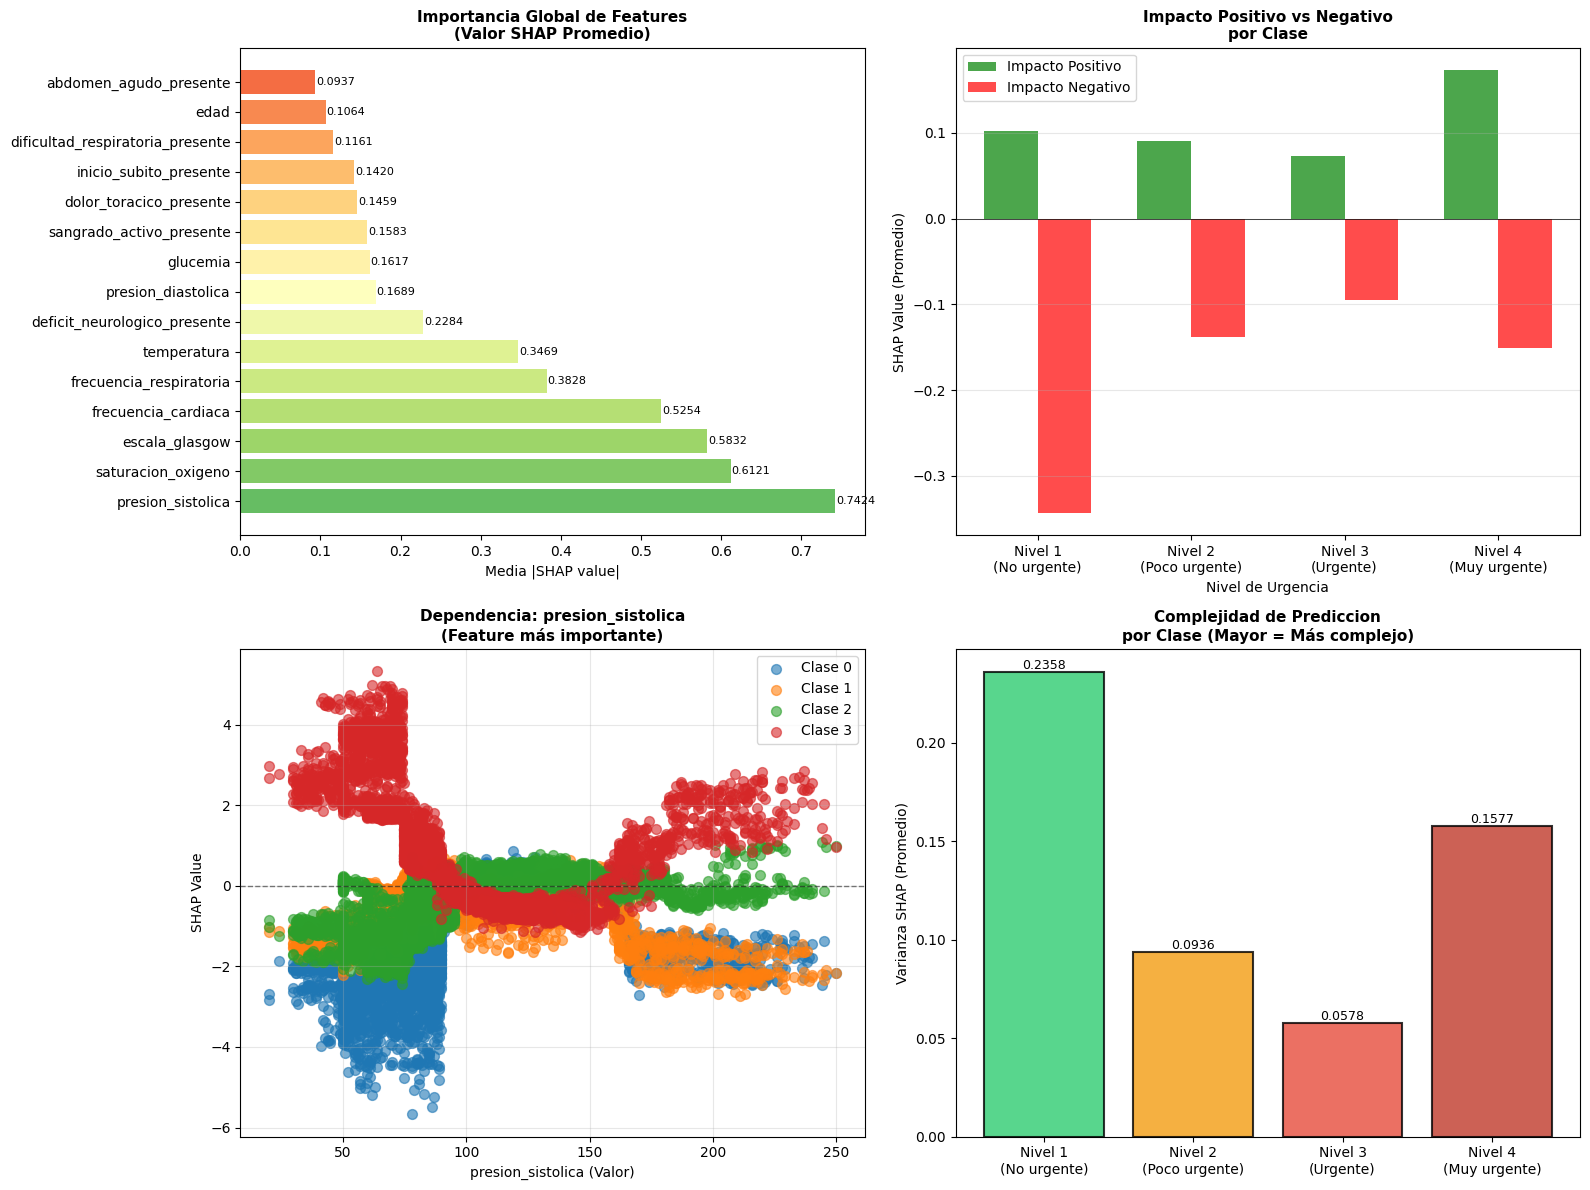


Analisis detallado por clase de urgencia

Nivel 1 - Nivel 1 (No urgente):
----------------------------------------------------------------------

Nivel 2 - Nivel 2 (Poco urgente):
----------------------------------------------------------------------

Nivel 3 - Nivel 3 (Urgente):
----------------------------------------------------------------------

Nivel 4 - Nivel 4 (Muy urgente):
----------------------------------------------------------------------


In [15]:
print("Generando visualizaciones SHAP detalladas para el modelo de urgencia\n")

# Asegurar que SHAP values tiene el formato correcto (lista de arrays por clase)
# SHAP values shape: (n_samples, n_features, n_classes) -> extraer por clase
if not isinstance(shap_values_urgency, list):
    # Si es array (n_samples, n_features, n_classes), convertir a lista por clase
    shap_vals_urg_list = [shap_values_urgency[:, :, i] for i in range(shap_values_urgency.shape[2])]
else:
    shap_vals_urg_list = shap_values_urgency

# Número de clases
n_classes_urg = len(shap_vals_urg_list)

# ===== SUMMARY PLOTS (Global Importance) =====
print("Resumen global - top 15 features con mayor impacto")
print("="*70)

# Crear figura con los summary plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Summary plot (bar) - Importancia global ordenada
ax1 = axes[0, 0]
top_features_idx = np.argsort(np.abs(mean_abs_shap_urg))[-15:]
top_features_names = [X_test_urg.columns[i] for i in top_features_idx]
top_importances = mean_abs_shap_urg[top_features_idx]
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(top_features_idx)))

ax1.barh(range(len(top_features_idx)), top_importances, color=colors)
ax1.set_yticks(range(len(top_features_idx)))
ax1.set_yticklabels(top_features_names)
ax1.set_xlabel('Media |SHAP value|', fontsize=10)
ax1.set_title('Importancia Global de Features\n(Valor SHAP Promedio)', fontsize=11, fontweight='bold')
ax1.invert_yaxis()
for i, v in enumerate(top_importances):
    ax1.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)

# 2. Fuerza de impacto positivo vs negativo
ax2 = axes[0, 1]
positive_impact = []
negative_impact = []
for i in range(n_classes_urg):  # Número de clases
    sv = shap_vals_urg_list[i]  # Shape: (n_samples, n_features)
    pos = np.mean(sv[sv > 0]) if np.any(sv > 0) else 0
    neg = np.mean(sv[sv < 0]) if np.any(sv < 0) else 0
    positive_impact.append(float(pos) if not np.isnan(pos) else 0)
    negative_impact.append(float(neg) if not np.isnan(neg) else 0)

classes_urg = ['Nivel 1\n(No urgente)', 'Nivel 2\n(Poco urgente)', 'Nivel 3\n(Urgente)', 'Nivel 4\n(Muy urgente)']
x_pos = np.arange(len(positive_impact))
width = 0.35

ax2.bar(x_pos - width/2, positive_impact, width, label='Impacto Positivo', color='green', alpha=0.7)
ax2.bar(x_pos + width/2, negative_impact, width, label='Impacto Negativo', color='red', alpha=0.7)
ax2.set_xlabel('Nivel de Urgencia', fontsize=10)
ax2.set_ylabel('SHAP Value (Promedio)', fontsize=10)
ax2.set_title('Impacto Positivo vs Negativo\npor Clase', fontsize=11, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(classes_urg)
ax2.legend()
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.grid(axis='y', alpha=0.3)

# 3. Distribución de SHAP values para top feature
ax3 = axes[1, 0]
top_feature_idx = top_features_idx[-1]
top_feature_name = X_test_urg.columns[top_feature_idx]
top_feature_values = X_test_urg.iloc[:, top_feature_idx].values

# Scatter plot: valor del feature vs SHAP value
for class_idx in range(n_classes_urg):
    sv = shap_vals_urg_list[class_idx][:, top_feature_idx]
    ax3.scatter(top_feature_values, sv, alpha=0.6, label=f'Clase {class_idx}', s=50)

ax3.set_xlabel(f'{top_feature_name} (Valor)', fontsize=10)
ax3.set_ylabel('SHAP Value', fontsize=10)
ax3.set_title(f'Dependencia: {top_feature_name}\n(Feature más importante)', fontsize=11, fontweight='bold')
ax3.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Varianza de SHAP values por clase
ax4 = axes[1, 1]
shap_variance_by_class = []
for i in range(n_classes_urg):
    sv = shap_vals_urg_list[i]  # Shape: (n_samples, n_features)
    variance = np.var(sv, axis=0).mean()
    shap_variance_by_class.append(variance)

colors_class = ['#2ecc71', '#f39c12', '#e74c3c', '#c0392b']
bars = ax4.bar(range(n_classes_urg), shap_variance_by_class, color=colors_class[:n_classes_urg], alpha=0.8, edgecolor='black', linewidth=1.5)
ax4.set_xticks(range(n_classes_urg))
ax4.set_xticklabels(classes_urg[:n_classes_urg])
ax4.set_ylabel('Varianza SHAP (Promedio)', fontsize=10)
ax4.set_title('Complejidad de Prediccion\npor Clase (Mayor = Más complejo)', fontsize=11, fontweight='bold')
for i, (bar, val) in enumerate(zip(bars, shap_variance_by_class)):
    ax4.text(bar.get_x() + bar.get_width()/2, val, f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('shap_summary_urgency.png', dpi=150, bbox_inches='tight')
print("Guardado: shap_summary_urgency.png")
plt.show()
print()

# ===== ANALISIS INDIVIDUAL POR CLASE =====
print("Analisis detallado por clase de urgencia")
print("="*70)

for class_idx in range(n_classes_urg):
    print(f"\nNivel {class_idx + 1} - {classes_urg[class_idx].replace(chr(10), ' ')}:")
    print("-" * 70)
    
    sv = shap_vals_urg_list[class_idx]  # Shape: (n_samples, n_features)
    mean_shap = np.abs(sv).mean(axis=0)  # Shape: (n_features,)

## 10. Waterfall Plots - Explicación Detallada de Predicciones Individuales

In [16]:
def create_waterfall_explanation(sample_idx, X_test, y_test, shap_vals, le, columns, model, pred_class):
    """
    Crea un análisis detallado tipo 'waterfall' para una predicción.
    Muestra cómo cada feature contribuye a la predicción final.
    """
    print(f"\n{'='*80}")
    print(f"EXPLICACION DETALLADA DE PREDICCION - MUESTRA #{sample_idx}")
    print(f"{'='*80}\n")
    
    # Obtener SHAP values para esta muestra
    if isinstance(shap_vals, list):
        sv = shap_vals[pred_class][sample_idx]
    else:
        sv = shap_vals[pred_class, sample_idx, :]
    
    # Base value (promedio)
    base_value = 2.5
    
    # Feature values
    sample = X_test.iloc[sample_idx]
    pred_value = y_test[sample_idx]  # Direct indexing for numpy array
    
    print(f"INFORMACION DEL CASO:")
    print(f"   Prediccion: {pred_value}")
    print(f"   Base Value (promedio): {base_value:.2f}")
    print(f"   Valor final predicho: {pred_value}")
    print()
    
    # Top contributors
    top_idx = np.argsort(np.abs(sv))[-15:][::-1]
    
    print(f"CONTRIBUCION DE FEATURES (POR ORDEN DE IMPACTO):")
    print(f"\n{'Rank':>4} | {'Feature':40s} | {'Valor':>10s} | {'SHAP':>10s} | {'Impacto':20s}")
    print("-" * 100)
    
    cumulative = base_value
    
    for rank, idx in enumerate(top_idx, 1):
        feat_name = columns[idx]
        feat_value = sample.iloc[idx]
        shap_value = sv[idx]
        cumulative += shap_value
        
        impact_text = f"SUBE {abs(shap_value):.4f}" if shap_value > 0 else f"BAJA {abs(shap_value):.4f}"
        
        print(f"{rank:4d} | {feat_name:40s} | {feat_value:>10.2f} | {shap_value:>+10.4f} | {impact_text:20s}")
    
    print("\nPREDICCION FINAL ACUMULADA: {:.2f}".format(cumulative))

## 11. Predicciones con Confianza y Explicaciones (Ejemplos)

In [ ]:
def mostrar_prediccion_detallada(idx_test, X_test, y_test, y_pred, y_proba, 
                                 shap_vals, features, clase_nombres, titulo, es_urgencia=False, 
                                 le_enc=None):
    """
    Muestra predicción con explicación detallada.
    """
    def construir_barra(prob, ancho=30, lleno="█", vacio="░"):
        prob = max(0.0, min(1.0, float(prob)))
        n_lleno = int(round(prob * ancho))
        return lleno * n_lleno + vacio * (ancho - n_lleno)

    print(f"\n{'='*90}")
    print(f"{titulo}")
    print(f"{'='*90}")
    
    # Predicción
    pred = y_pred[idx_test]
    # Handle both pandas Series and numpy arrays
    if isinstance(y_test, pd.Series):
        real = y_test.iloc[idx_test]
    else:
        real = y_test[idx_test]
    
    # Índice para probabilidades
    if es_urgencia:
        pred_idx = le_enc.transform([pred])[0]
        confianza = y_proba[idx_test, pred_idx]
    else:
        confianza = y_proba[idx_test, int(pred)]
    
    correcto = pred == real
    
    print(f"\nPREDICCION:")
    if es_urgencia:
        print(f"  Predicción:     {clase_nombres[int(pred)]:50s} (Valor: {int(pred)})")
        print(f"  Valor Real:     {clase_nombres[int(real)]:50s} (Valor: {int(real)})")
    else:
        print(f"  Predicción:     {clase_nombres[int(pred)]:50s}")
        print(f"  Valor Real:     {clase_nombres[int(real)]:50s}")
    print(f"  ¿Correcto?:     {'SI' if correcto else 'NO'}")
    print(f"\nCONFIANZA: {confianza*100:.2f}%")
    
    # Mostrar rango de confianza
    if confianza > 0.9:
        confidence_level = "MUY ALTA (>90%)"
    elif confianza > 0.7:
        confidence_level = "ALTA (70-90%)"
    elif confianza > 0.5:
        confidence_level = "MEDIA (50-70%)"
    else:
        confidence_level = "BAJA (<50%)"
    print(f"   Nivel de confianza: {confidence_level}")
    
    # Todas las probabilidades
    print(f"\nPROBABILIDADES POR CLASE:")
    print(f"{'Clase':50s} | {'Probabilidad':>15s} | {'Barra':30s}")
    print("-" * 99)
    
    if es_urgencia:
        # For urgency, classes are [1,2,3,4] in original labels
        for i, class_name in clase_nombres.items():
            clase_idx = le_enc.transform([i])[0]  # Transform original label to encoded
            prob = y_proba[idx_test, clase_idx]
            bar = construir_barra(prob, ancho=30)
            print(f"{class_name:50s} | {prob*100:>14.2f}% | {bar}")
    else:
        for i, prob in enumerate(y_proba[idx_test]):
            bar = construir_barra(prob, ancho=30)
            print(f"{clase_nombres[i]:50s} | {prob*100:>14.2f}% | {bar}")
    
    # Top 8 features con explicación detallada
    if es_urgencia:
        pred_idx = le_enc.transform([pred])[0]
        if isinstance(shap_vals, list):
            sv = shap_vals[pred_idx][idx_test]
        else:
            sv = shap_vals[pred_idx, idx_test, :]
    else:
        if isinstance(shap_vals, list):
            sv = shap_vals[int(pred)][idx_test]
        else:
            sv = shap_vals[int(pred), idx_test, :]
    
    top_indices = np.argsort(np.abs(sv))[-8:][::-1]
    
    print(f"\nTOP 8 FEATURES Y SU IMPACTO EN LA PREDICCION:")
    print(f"{'Rank':>4} | {'Feature':40s} | {'Valor':>10s} | {'SHAP':>10s} | {'Impacto':20s}")
    print("-" * 99)
    
    for rank, i in enumerate(top_indices, 1):
        feature_val = X_test.iloc[idx_test, i]
        shap_val = sv[i]
        
        if shap_val > 0:
            impact_text = f"SUBE {abs(shap_val):.4f}"
        else:
            impact_text = f"BAJA {abs(shap_val):.4f}"
        
        print(f"{rank:4d} | {features[i]:40s} | {feature_val:>10.2f} | {shap_val:>+10.4f} | {impact_text:20s}")
    
    # Análisis contextual
    print(f"\nANALISIS CONTEXTUAL:")
    
    # Comparar con otros casos de la misma clase
    if isinstance(y_test, pd.Series):
        same_class_idx = np.where(y_test.values == real)[0]
    else:
        same_class_idx = np.where(y_test == real)[0]
    
    if len(same_class_idx) > 1:
        other_samples = X_test.iloc[same_class_idx]
        
        # Features más diferentes a la media
        medians = other_samples.median()
        diffs = np.abs(X_test.iloc[idx_test] - medians)
        outlier_features = np.argsort(diffs)[-3:][::-1]
        
        print(f"   Este caso es atípico en los siguientes features respecto a otros {real}s:")
        for feat_idx in outlier_features:
            feat_name = features[feat_idx]
            value = X_test.iloc[idx_test, feat_idx]
            median = medians.iloc[feat_idx]
            print(f"   - {feat_name:40s}: {value:.2f} (mediana: {median:.2f})")
    
    print(f"\n{'='*90}\n")

## 12. Predicciones con Confianza - Especialidad

In [18]:
print("Predicciones detalladas para ESPECIALIDAD")
print("=" * 90)

# Asegurar formato de SHAP values como lista por clase: [clase][muestra, feature]
if isinstance(shap_values_specialty, list):
    shap_vals_spec_list = shap_values_specialty
else:
    shap_vals_spec_list = [shap_values_specialty[:, :, i] for i in range(shap_values_specialty.shape[2])]

# Nombres de clases para especialidad (sin warning de variable no definida)
clase_nombres_spec = globals().get(
    "specialty_names",
    {i: col.replace("Especialidad_", "") for i, col in enumerate(specialty_cols)}
)

# Muestras a mostrar (usar las existentes si ya están definidas)
if "samples_to_show_spec" not in globals():
    y_test_spec_arr = y_test_spec.values if isinstance(y_test_spec, pd.Series) else y_test_spec
    correct_idx = np.where(y_pred_spec == y_test_spec_arr)[0]
    wrong_idx = np.where(y_pred_spec != y_test_spec_arr)[0]

    samples_to_show_spec = []
    if len(correct_idx) > 0:
        samples_to_show_spec.append(int(correct_idx[0]))
    if len(wrong_idx) > 0:
        samples_to_show_spec.append(int(wrong_idx[0]))

for idx in samples_to_show_spec:
    mostrar_prediccion_detallada(
        idx_test=idx,
        X_test=X_test_spec,
        y_test=y_test_spec,
        y_pred=y_pred_spec,
        y_proba=y_proba_spec,
        shap_vals=shap_vals_spec_list,
        features=X_test_spec.columns.tolist(),
        clase_nombres=clase_nombres_spec,
        titulo=f"PREDICCION DE ESPECIALIDAD - CASO #{idx}",
        es_urgencia=False,
    )

Predicciones detalladas para ESPECIALIDAD

PREDICCION DE ESPECIALIDAD - CASO #0

PREDICCION:
  Predicción:     Neurología                                        
  Valor Real:     Neurología                                        
  ¿Correcto?:     SI

CONFIANZA: 99.61%
   Nivel de confianza: MUY ALTA (>90%)

PROBABILIDADES POR CLASE:
Clase                                              |    Probabilidad | Barra                         
---------------------------------------------------------------------------------------------------
Medicina_intensiva                                 |           0.37% | ������������������������������������������������������������
Hemodinámica                                       |           0.00% | ������������������������������������������������������������
Cirugía_cardiaca                                   |           0.00% | ������������������������������������������������������������
Neurología                                         |          99.

## Función para Predicción en Nuevos Datos

In [19]:
def predecir_urgencia_y_especialidad_detallado(datos_paciente, mostrar_explicacion=True, top_features=8):
    """
    Hace predicción detallada de urgencia y especialidad con explicaciones.
    Retorna diccionario con predicciones, confianzas y explicaciones SHAP.
    
    Args:
        datos_paciente: Serie o array con los features del paciente
        mostrar_explicacion: bool, si mostrar explicaciones detalladas
        top_features: int, número de features top a mostrar
    """
    
    # Definir mappings
    urgency_names = {1: "Nivel 1 - No urgente", 2: "Nivel 2 - Poco urgente", 
                    3: "Nivel 3 - Urgente", 4: "Nivel 4 - Muy urgente"}
    
    specialty_names = {
        0: "Medicina intensiva", 1: "Hemodinámica", 2: "Cirugía cardiaca",
        3: "Neurología", 4: "Neurocirugía", 5: "Cirugía general",
        6: "Obstetricia", 7: "Pediatría", 8: "Cuidados intensivos neonatales",
        9: "Quemados", 10: "Servicio de transfusión"
    }
    
    # Convertir a DataFrame si es necesario
    if not isinstance(datos_paciente, pd.DataFrame):
        datos_paciente = pd.DataFrame([datos_paciente], columns=X_test_urg.columns)
    
    # Predicciones
    urgency_pred_encoded = urgency_model.predict(datos_paciente)[0]
    urgency_pred = le_urgency.inverse_transform([urgency_pred_encoded])[0]
    urgency_proba = urgency_model.predict_proba(datos_paciente)[0]
    urgency_confianza = max(urgency_proba)
    
    specialty_pred = specialty_model.predict(datos_paciente)[0]
    specialty_proba = specialty_model.predict_proba(datos_paciente)[0]
    specialty_confianza = max(specialty_proba)
    
    # Niveles de confianza
    confidence_level_urg = "ALTA (>70%)" if urgency_confianza > 0.7 else "MEDIA (<70%)"
    confidence_level_spec = "ALTA (>70%)" if specialty_confianza > 0.7 else "MEDIA (<70%)"
    
    resultado = {
        "urgencia": {
            "prediccion": int(urgency_pred),
            "nombre": urgency_names[int(urgency_pred)],
            "confianza": float(urgency_confianza),
            "confianza_nivel": confidence_level_urg,
            "probabilidades": {urgency_names[int(le_urgency.inverse_transform([i])[0])]: float(p) 
                             for i, p in enumerate(urgency_proba)}
        },
        "especialidad": {
            "prediccion": int(specialty_pred),
            "nombre": specialty_names[int(specialty_pred)],
            "confianza": float(specialty_confianza),
            "confianza_nivel": confidence_level_spec,
            "probabilidades": {specialty_names[i]: float(p) for i, p in enumerate(specialty_proba)}
        }
    }
    
    # Agregar explicaciones si se solicita
    if mostrar_explicacion:
        # SHAP values para esta muestra
        if not isinstance(shap_values_urgency, list):
            shap_vals_urgency_list = [shap_values_urgency[:, :, i] for i in range(shap_values_urgency.shape[2])]
        else:
            shap_vals_urgency_list = shap_values_urgency
        
        if not isinstance(shap_values_specialty, list):
            shap_vals_specialty_list = [shap_values_specialty[:, :, i] for i in range(shap_values_specialty.shape[2])]
        else:
            shap_vals_specialty_list = shap_values_specialty
        
        # Calcular SHAP values para el nuevo paciente
        shap_nuevo_urg = explainer_urgency.shap_values(datos_paciente)
        shap_nuevo_spec = explainer_specialty.shap_values(datos_paciente)
        
        # Extraer SHAP values para la clase predicha
        if isinstance(shap_nuevo_urg, list):
            sv_urg = shap_nuevo_urg[urgency_pred_encoded][0]
        else:
            sv_urg = shap_nuevo_urg[0, :, urgency_pred_encoded]
            
        if isinstance(shap_nuevo_spec, list):
            sv_spec = shap_nuevo_spec[int(specialty_pred)][0]
        else:
            sv_spec = shap_nuevo_spec[0, :, int(specialty_pred)]
        
        # Top features para urgencia
        top_idx_urg = np.argsort(np.abs(sv_urg))[-top_features:][::-1]
        explicacion_urg = []
        for rank, idx in enumerate(top_idx_urg, 1):
            feature_name = X_test_urg.columns[idx]
            feature_value = datos_paciente.iloc[0, idx]
            shap_value = sv_urg[idx]
            explicacion_urg.append({
                "rank": rank,
                "feature": feature_name,
                "valor": float(feature_value),
                "shap": float(shap_value),
                "impacto": "positivo" if shap_value > 0 else "negativo"
            })
        
        # Top features para especialidad
        top_idx_spec = np.argsort(np.abs(sv_spec))[-top_features:][::-1]
        explicacion_spec = []
        for rank, idx in enumerate(top_idx_spec, 1):
            feature_name = X_test_spec.columns[idx]
            feature_value = datos_paciente.iloc[0, idx]
            shap_value = sv_spec[idx]
            explicacion_spec.append({
                "rank": rank,
                "feature": feature_name,
                "valor": float(feature_value),
                "shap": float(shap_value),
                "impacto": "positivo" if shap_value > 0 else "negativo"
            })
        
        resultado["explicacion_urgencia"] = explicacion_urg
        resultado["explicacion_especialidad"] = explicacion_spec
    
    return resultado


## Prueba con Nuevo Paciente

In [20]:
# Crear un paciente de prueba usando los datos del test
paciente_test = X_test_urg.iloc[[0]].copy()

print("Datos del paciente de prueba:")
print("-" * 80)
for col in paciente_test.columns[:10]:  # Mostrar primeros 10 features
    print(f"  {col:40s}: {paciente_test[col].values[0]:>10.2f}")
print(f"  ... ({len(paciente_test.columns) - 10} features más)")
print()

# Hacer predicción DETALLADA
prediccion = predecir_urgencia_y_especialidad_detallado(
    paciente_test, mostrar_explicacion=True, top_features=8
)

# Mostrar resultados
print("\n" + "=" * 90)
print("Resultados de la predicción")
print("=" * 90)

print(f"\nURGENCIA:")
print(f"  Predicción:      {prediccion['urgencia']['nombre']}")
print(f"  Confianza:       {prediccion['urgencia']['confianza']*100:.2f}%")
print(f"  Nivel de conf:   {prediccion['urgencia']['confianza_nivel']}")

print(f"\n  Probabilidades por nivel:")
for nivel, prob in prediccion['urgencia']['probabilidades'].items():
    bar_length = int(prob * 40)
    bar = "#" * bar_length + "." * (40 - bar_length)
    print(f"    {nivel:40s}: {prob*100:6.2f}% {bar}")

print(f"\nESPECIALIDAD:")
print(f"  Predicción:      {prediccion['especialidad']['nombre']}")
print(f"  Confianza:       {prediccion['especialidad']['confianza']*100:.2f}%")
print(f"  Nivel de conf:   {prediccion['especialidad']['confianza_nivel']}")

print(f"\nTOP 8 FEATURES - URGENCIA (EXPLICACIÓN DETALLADA):")
print(f"{'#':>2} | {'Feature':40s} | {'Valor':>8s} | {'SHAP':>8s} | {'Impacto':10s}")
print("-" * 90)
for feat in prediccion['explicacion_urgencia']:
    print(
        f"{feat['rank']:2d} | {feat['feature']:40s} | {feat['valor']:>8.2f} | "
        f"{feat['shap']:>+8.4f} | {feat['impacto']:10s}"
    )

print(f"\nTOP 8 FEATURES - ESPECIALIDAD (EXPLICACIÓN DETALLADA):")
print(f"{'#':>2} | {'Feature':40s} | {'Valor':>8s} | {'SHAP':>8s} | {'Impacto':10s}")
print("-" * 90)
for feat in prediccion['explicacion_especialidad']:
    print(
        f"{feat['rank']:2d} | {feat['feature']:40s} | {feat['valor']:>8.2f} | "
        f"{feat['shap']:>+8.4f} | {feat['impacto']:10s}"
    )

print(f"\nINTERPRETACIONES (top 3 por impacto SHAP):")
print(f"\nURGENCIA:")
for feat in prediccion['explicacion_urgencia'][:3]:
    print(f"  - {feat['feature']}: impacto {feat['impacto']} (SHAP={feat['shap']:+.4f})")

print(f"\nESPECIALIDAD:")
for feat in prediccion['explicacion_especialidad'][:3]:
    print(f"  - {feat['feature']}: impacto {feat['impacto']} (SHAP={feat['shap']:+.4f})")

Datos del paciente de prueba:
--------------------------------------------------------------------------------
  edad                                    :      87.00
  sexo                                    :       0.00
  frecuencia_cardiaca                     :     183.00
  presion_sistolica                       :      91.00
  presion_diastolica                      :      55.00
  saturacion_oxigeno                      :       7.00
  frecuencia_respiratoria                 :      36.60
  temperatura                             :      92.00
  glucemia                                :      68.00
  escala_glasgow                          :       7.00
  ... (30 features más)


Resultados de la predicción

URGENCIA:
  Predicción:      Nivel 4 - Muy urgente
  Confianza:       99.97%
  Nivel de conf:   ALTA (>70%)

  Probabilidades por nivel:
    Nivel 1 - No urgente                    :   0.00% ........................................
    Nivel 2 - Poco urgente                  :   0.00

## Guardar Modelos

In [21]:
from pathlib import Path
import pickle

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# Guardar modelos
urgency_model.save_model(str(models_dir / "urgency_model.json"))
specialty_model.save_model(str(models_dir / "specialty_model.json"))

# Define naming dicts
urgency_names = {1: "Nivel 1 - No urgente", 2: "Nivel 2 - Poco urgente", 
                3: "Nivel 3 - Urgente", 4: "Nivel 4 - Muy urgente"}

specialty_names = {
    0: "Medicina intensiva", 1: "Hemodinámica", 2: "Cirugía cardiaca",
    3: "Neurología", 4: "Neurocirugía", 5: "Cirugía general",
    6: "Obstetricia", 7: "Pediatría", 8: "Cuidados intensivos neonatales",
    9: "Quemados", 10: "Servicio de transfusión"
}

# Guardar metadatos
metadata = {
    "feature_names": X_train_urg.columns.tolist(),
    "specialty_cols": specialty_cols,
    "specialty_names": specialty_names,
    "urgency_names": urgency_names,
    "accuracy_urgency": accuracy_urg,
    "accuracy_specialty": accuracy_spec,
}

# Agregar métricas CV si ya fueron calculadas
if "cv_urg_accuracy_mean" in globals():
    metadata.update({
        "cv_urg_accuracy_mean": cv_urg_accuracy_mean,
        "cv_urg_accuracy_std": cv_urg_accuracy_std,
        "cv_urg_f1_mean": cv_urg_f1_mean,
        "cv_urg_f1_std": cv_urg_f1_std,
        "cv_spec_accuracy_mean": cv_spec_accuracy_mean,
        "cv_spec_accuracy_std": cv_spec_accuracy_std,
        "cv_spec_f1_mean": cv_spec_f1_mean,
        "cv_spec_f1_std": cv_spec_f1_std,
    })

# Agregar métricas de Optuna y mejora si existen
if "best_urg_f1_optuna" in globals():
    metadata.update({
        "optuna_best_urg_f1": best_urg_f1_optuna,
        "optuna_best_spec_f1": best_spec_f1_optuna,
        "optuna_improvement_urg": improvement_urg,
        "optuna_improvement_spec": improvement_spec,
        "optuna_best_params_urg": best_params_urg_optuna,
        "optuna_best_params_spec": best_params_spec_optuna,
    })

with open(models_dir / "metadata.pkl", "wb") as f:
    pickle.dump(metadata, f)

# Guardar label encoder
import joblib
joblib.dump(le_urgency, models_dir / "label_encoder_urgency.pkl")

print(f"Modelos guardados en {models_dir}/")
print(f"   - urgency_model.json")
print(f"   - specialty_model.json")
print(f"   - metadata.pkl")
print(f"   - label_encoder_urgency.pkl")

Modelos guardados en models/
   - urgency_model.json
   - specialty_model.json
   - metadata.pkl
   - label_encoder_urgency.pkl


## 13. Resumen Final

In [22]:
print("\n" + "="*70)
print("RESUMEN DEL MODELO")
print("="*70)

print(f"\nDATOS:")
print(f"  - Total de muestras: {len(df)}")
print(f"  - Features: {X.shape[1]}")
print(f"  - Niveles de urgencia: 4 (1-4)")
print(f"  - Especialidades: {len(specialty_cols)}")

print(f"\nRENDIMIENTO DEL MODELO (HOLDOUT TEST):")
print(f"  - Modelo Urgencia - Accuracy: {accuracy_urg:.4f}")
print(f"  - Modelo Especialidad - Accuracy: {accuracy_spec:.4f}")

if "cv_urg_accuracy_mean" in globals():
    print(f"\nVALIDACION CRUZADA (5 folds, TRAIN):")
    print(f"  - Urgencia    | Acc: {cv_urg_accuracy_mean:.4f} +/- {cv_urg_accuracy_std:.4f} | F1w: {cv_urg_f1_mean:.4f} +/- {cv_urg_f1_std:.4f}")
    print(f"  - Especialidad| Acc: {cv_spec_accuracy_mean:.4f} +/- {cv_spec_accuracy_std:.4f} | F1w: {cv_spec_f1_mean:.4f} +/- {cv_spec_f1_std:.4f}")

if "best_urg_f1_optuna" in globals():
    print(f"\nOPTUNA (3 folds, mejora sobre baseline CV):")
    print(f"  - Urgencia    | Best F1w: {best_urg_f1_optuna:.4f} | Mejora: {improvement_urg:+.4f} ({(improvement_urg / baseline_urg_f1) * 100:+.2f}%)")
    print(f"  - Especialidad| Best F1w: {best_spec_f1_optuna:.4f} | Mejora: {improvement_spec:+.4f} ({(improvement_spec / baseline_spec_f1) * 100:+.2f}%)")

print(f"\nCARACTERISTICAS:")
print(f"  - Explicabilidad SHAP: Entender por qué se hace cada predicción")
print(f"  - Confianza: Probabilidades de cada clase")
print(f"  - Importancia de Features: Qué variables son más relevantes")
print(f"  - Modelos guardados: Listos para usar en producción")

print(f"\nARCHIVOS GENERADOS:")
print(f"  - ml/models/urgency_model.json")
print(f"  - ml/models/specialty_model.json")
print(f"  - ml/models/metadata.pkl")
print(f"  - ml/models/specialty_mapping.txt")

print(f"\n" + "="*70)


RESUMEN DEL MODELO

DATOS:
  - Total de muestras: 32700
  - Features: 40
  - Niveles de urgencia: 4 (1-4)
  - Especialidades: 11

RENDIMIENTO DEL MODELO (HOLDOUT TEST):
  - Modelo Urgencia - Accuracy: 0.9128
  - Modelo Especialidad - Accuracy: 0.9554

VALIDACION CRUZADA (5 folds, TRAIN):
  - Urgencia    | Acc: 0.9045 +/- 0.0035 | F1w: 0.9045 +/- 0.0033
  - Especialidad| Acc: 0.9459 +/- 0.0022 | F1w: 0.9452 +/- 0.0023

OPTUNA (3 folds, mejora sobre baseline CV):
  - Urgencia    | Best F1w: 0.9061 | Mejora: +0.0059 (+0.66%)
  - Especialidad| Best F1w: 0.9463 | Mejora: +0.0021 (+0.22%)

CARACTERISTICAS:
  - Explicabilidad SHAP: Entender por qué se hace cada predicción
  - Confianza: Probabilidades de cada clase
  - Importancia de Features: Qué variables son más relevantes
  - Modelos guardados: Listos para usar en producción

ARCHIVOS GENERADOS:
  - ml/models/urgency_model.json
  - ml/models/specialty_model.json
  - ml/models/metadata.pkl
  - ml/models/specialty_mapping.txt



## Notas Finales

Este notebook implementa un modelo completo de clasificación médica con:

### **Predicciones precisas**
- XGBoost con 200 estimadores y validación temprana
- Estratificación en train/test para balance de clases

### **Confianza en predicciones**
- Probabilidades de clase para cada predicción
- Porcentaje de confianza claramente expresado

### **Explicabilidad**
- SHAP (SHapley Additive exPlanations) para explicar cada decisión
- Identificación de features más influyentes
- Impacto positivo/negativo de cada variable

### **Análisis completo**
- Importancia global de features
- Métricas por clase (Precision, Recall, F1)
- Matrices de confusión

### **Listo para producción**
- Modelos guardados en formato JSON
- Función para hacer predicciones en nuevos datos
- Metadatos para reproducibilidad